# Path patching on viewpoint-rotation prompts

**Input:** two attributed, author-published VRUBench paper examples and matched final-action direction changes. **Models:** Qwen2.5-VL-3B and 7B (text-only inputs to VLMs). **Tool:** IOI-style Path Patching from each head to a final residual receiver. The full official dataset was not available when these snapshots were collected.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


In [2]:
from demos.path_helpers import load_pairs, effect_grid
from demos.path_display import prompt_cards
pairs = load_pairs(ASSETS / "vrubench_paper_samples.jsonl")
for pair in pairs:
    display(prompt_cards(pair))

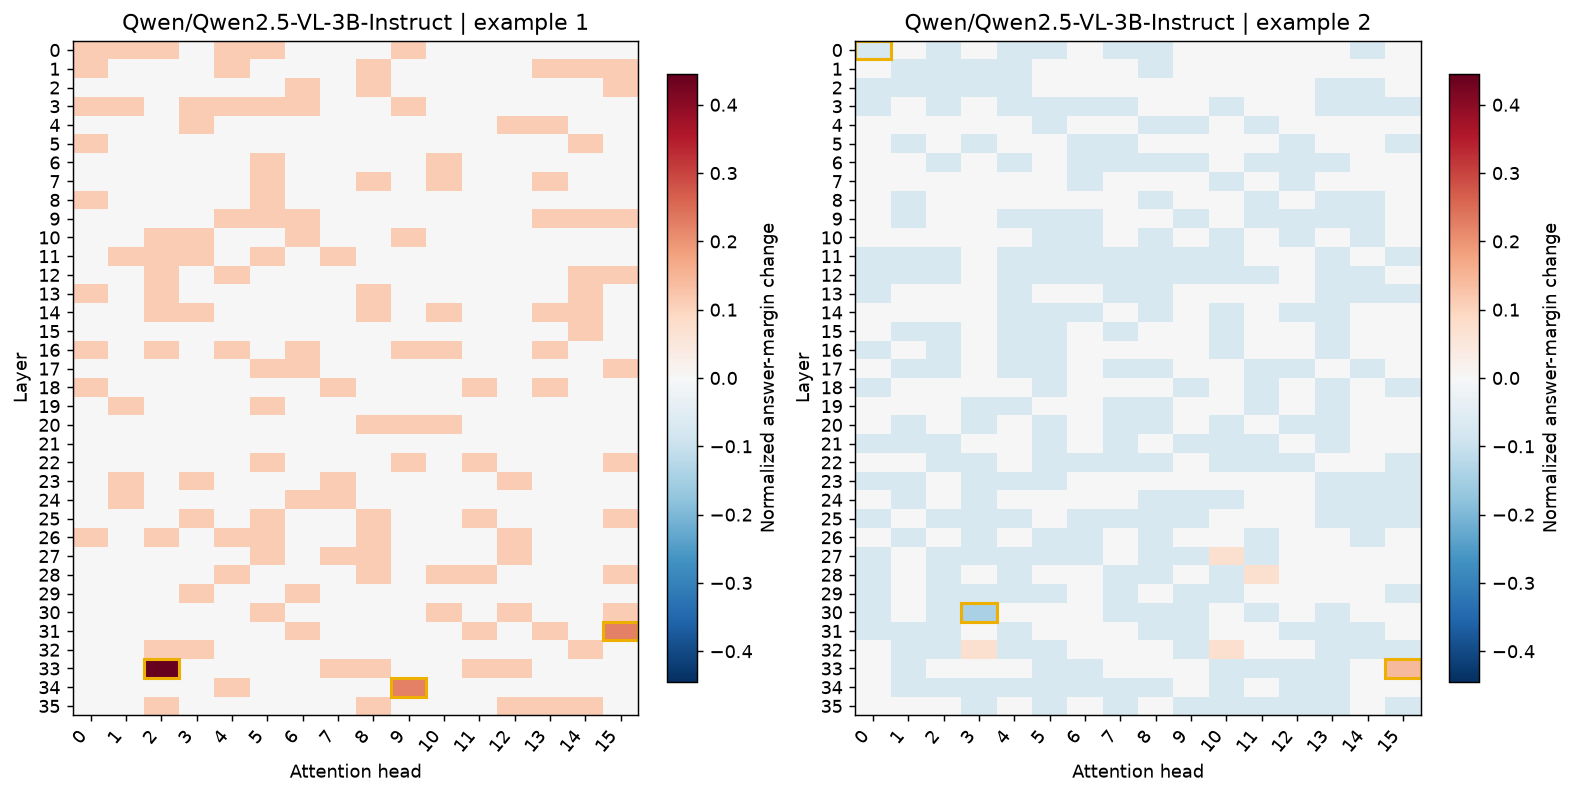

Clean margins: [4.125, 0.0] | reference margins: [5.25, -1.75]
Metric: float32 first-answer-token logit difference


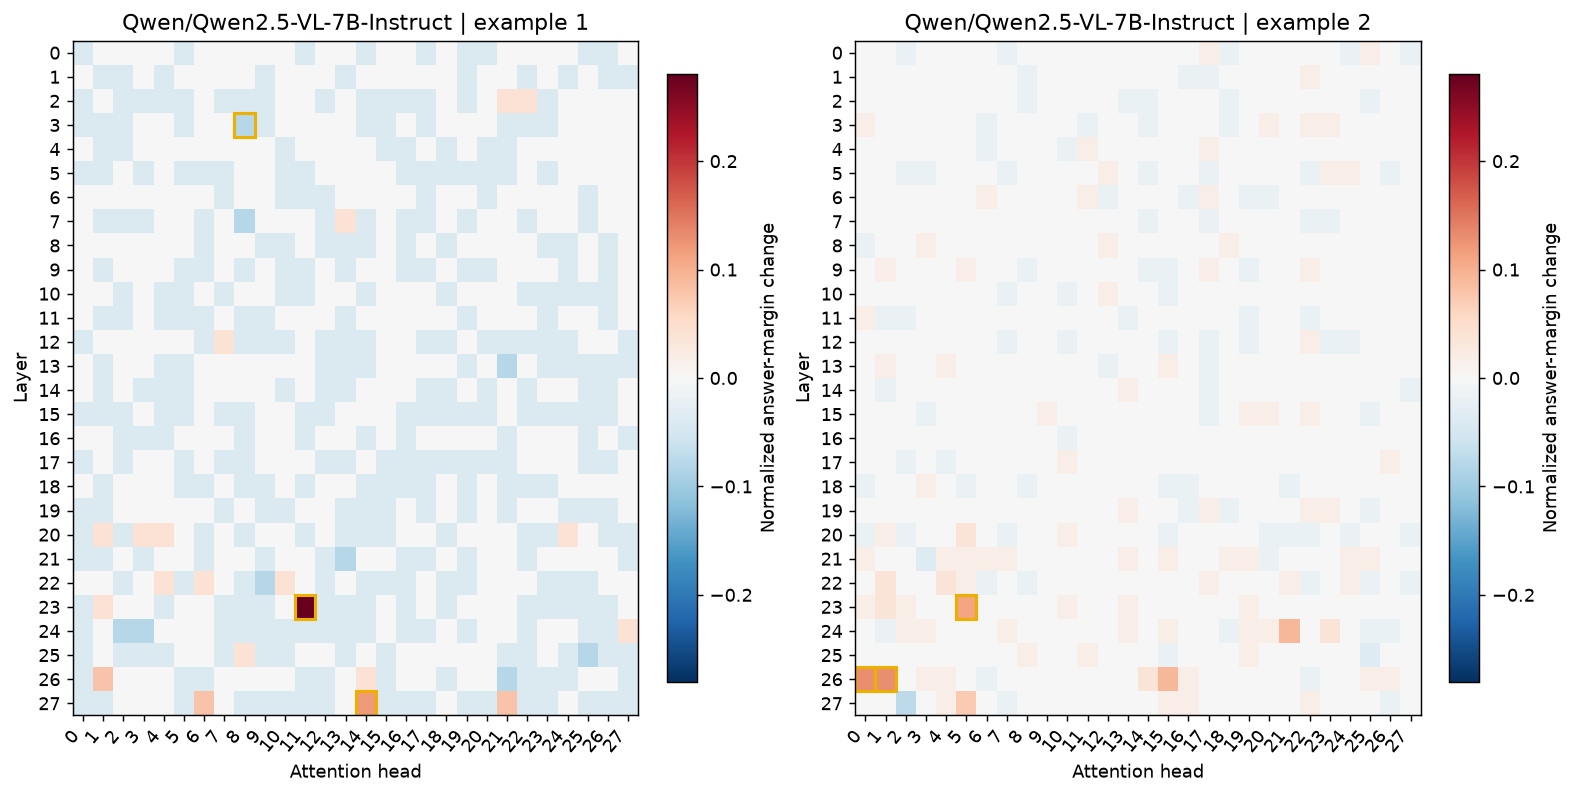

Clean margins: [2.25, -1.1875] | reference margins: [3.8125, -4.5625]
Metric: float32 first-answer-token logit difference


In [3]:
for size in ("3b", "7b"):
    record = load_snapshot(f"path_patching/qwen2_5_vl_{size}.json")
    effects = np.asarray(record["normalized_effect"])
    counts = {layer:record["shape"][1] for layer in range(record["shape"][0])}
    fig, axes = plt.subplots(1, len(pairs), figsize=(12,6), constrained_layout=True)
    limit = np.nanmax(np.abs(effects))
    for index,(ax,pair) in enumerate(zip(axes,pairs)):
        grid = effect_grid(counts, record["senders"], effects[:,index])
        plot_causal_heatmap(grid, ax=ax, column_labels=list(range(record["shape"][1])),
                            title=f"{record['model_id']} | example {index+1}",
                            value_label="Normalized answer-margin change", vmin=-limit, vmax=limit,
                            highlight_count=3)
        ax.set_xlabel("Attention head")
    show_figure(fig)
    print("Clean margins:",record["baseline_score"],"| reference margins:",record["donor_score"])
    print("Metric:",record["metric"])

**How to read:** each cell measures one genuine controlled forward intervention. During the controlled run, sender output is replaced with the reference-input value and all other head outputs are frozen to the base cache; MLP and LayerNorm recompute. A second fresh base run injects only the resulting receiver residual. Color is `(patched − base)/(reference − base)`, per example, without clipping. A near-zero denominator would be undefined. Highlighted heads have the largest absolute measured changes. This scan measures head-to-output paths; it does not automatically recover a complete circuit or assign functional head names.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [4]:
if RERUN:
    from demos.runtime import bind_model
    from demos.path_helpers import prepare_inputs, first_answer_metric, head_grid, normalized_effect
    probe, processor, device = bind_model("Qwen/Qwen2.5-VL-3B-Instruct", attention=False)
    tokenizer = processor.tokenizer
    clean, reference = prepare_inputs(pairs[0], processor, device)
    metric, token_info = first_answer_metric(pairs[0], tokenizer, clean_inputs=clean, donor_inputs=reference)
    senders = head_grid(probe)
    result = probe.causal.path(senders=senders, receivers="residual", sender_tokens="last_prompt").sweep(
        clean, donor=reference, metric=metric)
    normalized, eligible = normalized_effect(result)
    grid = effect_grid(probe, senders, normalized[:,0])
    ax = plot_causal_heatmap(grid, value_label="Normalized answer-margin change", highlight_count=3)
    show_figure(ax.figure)
    print("Candidate IDs verified in native prompt context:", token_info)
else:
    print("Fresh full-head scan skipped (multiple forwards per head).")

Fresh full-head scan skipped (multiple forwards per head).


## Sources and interpretation

**Method:** Wang et al., [Interpretability in the Wild](https://arxiv.org/abs/2211.00593), Appendix B / Algorithm 1, and [author implementation](https://github.com/redwoodresearch/Easy-Transformer). **Task:** [Viewpoint Rotation Interpretability](https://arxiv.org/abs/2604.15294), Appendix A 2-step prompt and Figure 7(c) 4-step prompt. These are paper examples, not the full 19,591-instance VRUBench release, and this is not the dataset-average Figure 2(d). The first changed-answer label is derived by the paper corruption rule; the second is published. Dataset hashes and source locations are in `assets/vrubench_provenance.json`.

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.